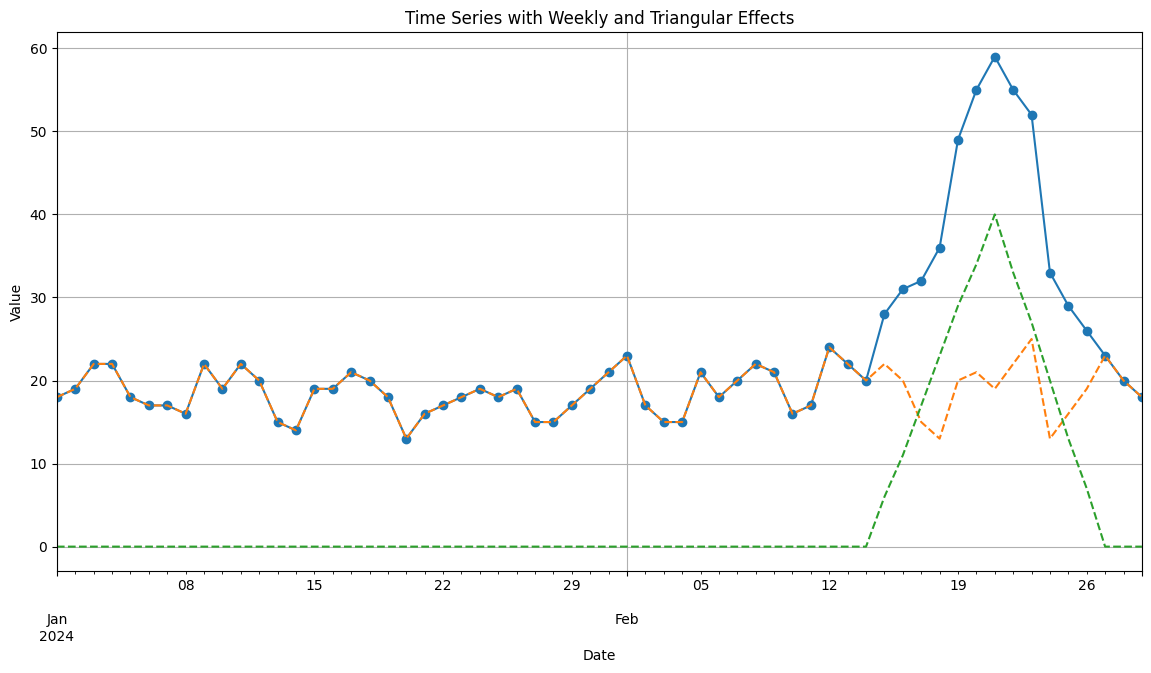

2024-01-01    18
2024-01-02    19
2024-01-03    22
2024-01-04    22
2024-01-05    18
Freq: D, dtype: int64


In [2]:
from ctypes import c_voidp

# using a gaussian distribution create a time series of points over 60 days that have a mean of 20 and a standard deviation of 5
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Parameters
days = 60
mean = 20
std_dev = 2

# Create a date range for 60 days
dates = pd.date_range(start='2024-01-01', periods=days, freq='D')

# Generate data points from a Gaussian distribution
baseline_data = np.random.normal(loc=mean, scale=std_dev, size=days)

# Add a weekly effect (e.g., higher values on weekends)
# dates.dayofweek returns Monday=0, ..., Sunday=6
weekly_effect = np.zeros(days)
# remove 15 to values on Saturday (5) and Sunday (6)

weekly_effect[dates.dayofweek >= 5] = 5
baseline_data = baseline_data - weekly_effect

# Add a triangular shaped effect for two weeks starting on day 14
triangular_effect = np.zeros(days)
start_day_tri = 45
duration_tri = 14
peak_value_tri = 40 # The peak of the triangle

# Create the rising part of the triangle
rising_part = np.linspace(0, peak_value_tri, num=duration_tri//2, endpoint=False)
# Create the falling part of the triangle
falling_part = np.linspace(peak_value_tri, 0, num=duration_tri - (duration_tri//2))

# Combine parts to form the triangle
triangle = np.concatenate([rising_part, falling_part])

# Add the triangle to the effect array at the correct position
start_index = start_day_tri - 1
end_index = start_index + duration_tri
triangular_effect[start_index:end_index] = triangle

outbreak_data = triangular_effect

# Convert to whole numbers
baseline_data = np.round(baseline_data).astype(int)
outbreak_data = np.round(outbreak_data).astype(int)

# Create a time series with pandas
time_series = pd.Series(baseline_data + outbreak_data, index=dates)
baseline_series = pd.Series(baseline_data, index=dates)
outbreak_series = pd.Series(outbreak_data, index=dates)


# Plot the time series
plt.figure(figsize=(14, 7))
time_series.plot(title='Time Series with Weekly and Triangular Effects', marker='o', linestyle='-')
baseline_series.plot(label='Baseline', linestyle='--')
outbreak_series.plot(label='Outbreak', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.show()

# Display the first 5 data points
print(time_series.head())


In [3]:
case_directory = '/Users/jue/IdeaProjects/PDS_Docker/mailboxes/ed_reports'

non_outbreak_reports = [
    'car_accident_discharge_report_1.txt',
    'car_accident_discharge_report_2.txt',
    'car_accident_discharge_report_3.txt',
    'car_accident_discharge_report_4.txt',
    'car_accident_discharge_report_5.txt',
    'heart_attack_discharge_report_1.txt',
    'heart_attack_discharge_report_2.txt',
    'heart_attack_discharge_report_3.txt',
    'heart_attack_discharge_report_4.txt',
    'heart_attack_discharge_report_5.txt',
    'stroke_discharge_report_1.txt',
    'stroke_discharge_report_2.txt',
    'stroke_discharge_report_3.txt',
    'stroke_discharge_report_4.txt',
    'stroke_discharge_report_5.txt'
]

adenovirus_cases = [
'adenovirus_discharge_report_1.txt',
'adenovirus_discharge_report_2.txt',
'adenovirus_discharge_report_3.txt',
'adenovirus_discharge_report_4.txt',
'adenovirus_discharge_report_5.txt']

enterovirus_cases = [
'enterovirus_discharge_report_1.txt',
'enterovirus_discharge_report_2.txt',
'enterovirus_discharge_report_3.txt',
'enterovirus_discharge_report_4.txt',
'enterovirus_discharge_report_5.txt'
]

covid_cases = [
'covid_discharge_report_1.txt',
'covid_discharge_report_2.txt',
'covid_discharge_report_3.txt',
'covid_discharge_report_4.txt',
'covid_discharge_report_5.txt']

hmpv_cases = [
'hmpv_discharge_report_1.txt',
'hmpv_discharge_report_2.txt',
'hmpv_discharge_report_3.txt',
'hmpv_discharge_report_4.txt',
'hmpv_discharge_report_5.txt']

parainfluenza_cases = [
'parainfluenza_discharge_report_1.txt',
'parainfluenza_discharge_report_2.txt',
'parainfluenza_discharge_report_3.txt',
'parainfluenza_discharge_report_4.txt',
'parainfluenza_discharge_report_5.txt']

rsv_cases = [
'rsv_discharge_report_1.txt',
'rsv_discharge_report_2.txt',
'rsv_discharge_report_3.txt',
'rsv_discharge_report_4.txt',
'rsv_discharge_report_5.txt']

non_outbreak_reports = non_outbreak_reports + adenovirus_cases + enterovirus_cases + hmpv_cases + parainfluenza_cases + rsv_cases

outbreak_reports = covid_cases

In [4]:
import os
import shutil
import random

# Define the destination directory
archive_directory = '/Users/jue/IdeaProjects/PDS_Docker/mailboxes/metamap_archive'

# Create the destination directory if it doesn't exist
os.makedirs(archive_directory, exist_ok=True)

def copy_reports_using_series(series, report_list, case_dir, dest_dir):
    for date, value in series.items():
        files_to_copy = random.choices(report_list, k=value)
        date_str = date.strftime('%Y%m%d')
        for i, filename in enumerate(files_to_copy):
            source_path = os.path.join(case_dir, filename)
            new_filename = f"{date_str}_{i+1}.txt"
            destination_path = os.path.join(dest_dir, new_filename)
            if os.path.exists(source_path):
                shutil.copy(source_path, destination_path)
            else:
                print(f"Warning: Source file not found - {source_path}")




print(f"Files have been copied to '{archive_directory}'")

Files have been copied to '/Users/jue/IdeaProjects/PDS_Docker/mailboxes/metamap_archive'


In [5]:
copy_reports_using_series(baseline_series, non_outbreak_reports, case_directory, archive_directory)

In [6]:
copy_reports_using_series(outbreak_series, outbreak_reports, case_directory, archive_directory)